# Prep: aspect-based sentiment (HoASA) with a multi-output neural network

Text + fastText/lexicon auxiliary features feeding a Keras model with one softmax head per hotel aspect (10 aspects).

In [ ]:
DATA_DIR = "../data"
FASTTEXT_MODEL_PATH = "../models/cc.id.300.bin"

In [172]:
import pandas as pd
import numpy as np
import nltk, string
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from stanza.pipeline.core import Pipeline
from nlp_id.stopword import StopWord
from nlp_id.lemmatizer import Lemmatizer
from nlp_id.tokenizer import Tokenizer
from nlp_id.postag import PosTag
from gensim.models.fasttext import load_facebook_model
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import keras.backend as K
import torch
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, TFBertModel, TrainingArguments, Trainer, \
    AutoModelForSequenceClassification, EarlyStoppingCallback
# import evaluate

from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.multioutput import MultiOutputClassifier

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [131]:
train_df = pd.read_csv(f"{DATA_DIR}/hoasa_absa-airy/train_preprocess.csv")
val_df = pd.read_csv(f"{DATA_DIR}/hoasa_absa-airy/valid_preprocess.csv")
df = pd.concat([train_df, val_df], ignore_index=True)
df.head()

,review,ac,air_panas,bau,general,kebersihan,linen,service,sunrise_meal,tv,wifi
0,kebersihan kurang...,neut,neut,neut,neut,neg,neut,neut,neut,neut,neut
1,"sangat mengecewakan... hotel bad image, kebers...",neut,neut,neut,neut,neg,neut,neut,neut,neut,neut
2,Tempat nyaman bersih tapi tv terlalu tinggi ti...,neut,neut,neut,neut,pos,neut,neut,neut,neg,neut
3,"semuanya bagus sesuai profile,dan harga promo ...",neut,neg,neut,pos,neut,neut,neut,neut,neut,neut
4,"Tempat tidur sangat keras, bantal besar dan ke...",neg,neg,neut,neut,neut,neg,neut,neut,neut,neut


In [132]:
df.ac.unique()

array(['neut', 'neg', 'pos', 'neg_pos'], dtype=object)

In [133]:
df.kebersihan.unique()

array(['neg', 'pos', 'neut', 'neg_pos'], dtype=object)

In [134]:
df.linen.unique()

array(['neut', 'neg', 'pos', 'neg_pos'], dtype=object)

In [135]:
df.service.unique()

array(['neut', 'neg', 'pos', 'neg_pos'], dtype=object)

In [136]:
for col in ['ac', 'kebersihan', 'linen', 'service']:
    df = df[df[col] != 'neg_pos']

In [137]:
labels = ['ac', 'air_panas', 'bau', 'general', 'kebersihan', 'linen', 'service', 'sunrise_meal', 'tv', 'wifi']

LABEL_MAP = {
    "neg": 0,
    "neut": 1,
    "pos": 2,
}

for label in labels:
    df[label] = df[label].map(LABEL_MAP)

df[labels].head()

,ac,air_panas,bau,general,kebersihan,linen,service,sunrise_meal,tv,wifi
0,1,1,1,1,0,1,1,1,1,1
1,1,1,1,1,0,1,1,1,1,1
2,1,1,1,1,2,1,1,1,0,1
3,1,0,1,2,1,1,1,1,1,1
4,0,0,1,1,1,0,1,1,1,1


In [140]:
# nlp_stanza = Pipeline('id',
#                       processors='tokenize,mwt,lemma',
#                       tokenize_pretokenized=True,
#                       )
stopwords = StopWord().get_stopword()
for word in ['kurang', 'tidak', 'baik']:
    stopwords.remove(word)
lemmatizer = Lemmatizer()
tokenizer = Tokenizer()
postagger = PosTag()

d:\miniconda3\envs\tf\lib\site-packages\sklearn\base.py:318: UserWarning: Trying to unpickle estimator DictVectorizer from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\miniconda3\envs\tf\lib\site-packages\sklearn\base.py:318: UserWarning: Trying to unpickle estimator DecisionTreeClassifier from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
d:\miniconda3\envs\tf\lib\site-packages\sklearn\base.py:318: UserWarning: Trying to unpickle estimator RandomForestClassifier from version 0.22 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own

In [141]:
def tokenize_lemmatize(text):
    lemmatized_doc = lemmatizer.lemmatize(text)
    return [word for word in tokenizer.tokenize(lemmatized_doc) if word not in stopwords]

In [142]:
df['review_tokenized'] = df['review'].apply(tokenize_lemmatize)
df['review_tokenized'].head()

0                                     [bersih, kurang]
1    [kecewa, hotel, bad, image, bersih, kurang, be...
2                   [nyaman, bersih, tv, tidak, lihat]
3    [bagus, sesuai, profile, harga, promo, suite, ...
4    [tidur, keras, bantal, besar, keras, air, pana...
Name: review_tokenized, dtype: object

In [143]:
# kita muat kata-kata bersentiment tersebut ke memori
# dalam bentuk python's dictionary
# key = word
# value = sentiment score

def load_sentword(filename):
    file = open(filename, "r")
    file.readline()  # skip header
    sentword_score = {}
    for line in file:
        word, score = line.strip().split("\t")
        score = int(score)
        sentword_score[word] = score
    file.close()
    return sentword_score


sentword_score_neg = load_sentword(f"{DATA_DIR}/negative.tsv")
sentword_score_pos = load_sentword(f"{DATA_DIR}/positive.tsv")


# num positives or negatives
def num(text, sentword_score):
    count = 0
    for word in text:
        if word in sentword_score:
            count += 1
    return count


# num JJ positives or negatives
def num_jj(text, sentword_score):
    count = 0
    for word, pos in postagger.get_pos_tag(" ".join(text)):
        if pos == "JJ":
            if word in sentword_score:
                count += 1
    return count


# print(sentword_score)
print(sentword_score_neg['mencederai'])
print(sentword_score_pos['bagus'])

-4
2


In [144]:
df["num_pos_review"] = df.review_tokenized. \
    map(lambda x: num(x, sentword_score_pos))

df["num_neg_review"] = df.review_tokenized. \
    map(lambda x: num(x, sentword_score_neg))

df["num_jj_pos_review"] = df.review_tokenized. \
    map(lambda x: num_jj(x, sentword_score_pos))

df["num_jj_neg_review"] = df.review_tokenized. \
    map(lambda x: num_jj(x, sentword_score_neg))

In [19]:
ft_model = load_facebook_model(FASTTEXT_MODEL_PATH)

In [24]:
ft_model.wv.most_similar('bau', topn=10)

[('baunya', 0.7502307891845703),
 ('aroma', 0.7469097375869751),
 ('bebauan', 0.693617045879364),
 ('amisnya', 0.6651269197463989),
 ('bau-bau', 0.6515205502510071),
 ('Bau', 0.6508873701095581),
 ('kebauan', 0.6447656154632568),
 ('Baunya', 0.6422731876373291),
 ('aroma-aroma', 0.6393709182739258),
 ('bau-bauan', 0.638985276222229)]

In [145]:
embedded_words = [[ft_model.wv[word] for word in token] for token in tqdm(df['review_tokenized'].tolist())]
embedded_words_encoding = [np.mean(embedded_word, axis=0) for embedded_word in tqdm(embedded_words)]
df_embedding = pd.DataFrame(embedded_words_encoding)
df_embedding.head()

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,0.014576,-0.012226,0.010872,-0.005993,-0.037455,-0.033761,0.015371,0.030564,-0.005571,-0.073500,...,0.001116,0.009118,-0.005093,0.015666,0.031078,0.043594,0.035579,0.027885,0.016291,0.058492
1,0.030862,-0.008655,-0.036939,-0.002987,-0.023031,-0.022818,-0.004973,0.061382,-0.027084,-0.106324,...,0.009355,0.043653,-0.005753,-0.004318,-0.031764,0.036990,0.013729,-0.019661,0.006475,0.080892
2,0.038952,-0.088017,-0.075425,0.091268,0.083751,-0.034244,-0.010679,-0.005332,0.008505,-0.133953,...,-0.018707,0.071034,-0.055746,0.044338,0.016490,0.036182,0.003229,0.017204,0.010311,-0.021546
3,0.016353,-0.042991,-0.021139,0.066199,0.013024,-0.014415,-0.026430,0.059945,-0.007524,-0.096005,...,0.041994,0.021612,-0.013443,-0.017539,0.046575,0.051448,0.009958,-0.018741,0.042781,0.064199
4,0.043537,-0.044296,0.009503,0.047476,-0.031511,-0.060081,-0.036310,0.036362,-0.020610,-0.079096,...,0.008068,0.009851,0.001524,0.029341,0.016110,0.035129,0.034869,-0.002092,0.005848,0.023731


In [26]:
def tsne_plot(for_word, w2v_model):
    # trained fastText model dimention
    dim_size = w2v_model.wv.vectors.shape[1]

    arrays = np.empty((0, dim_size), dtype='f')
    word_labels = [for_word]
    color_list = ['red']

    # adds the vector of the query word
    arrays = np.append(arrays, w2v_model.wv.__getitem__([for_word]), axis=0)

    # gets list of most similar words
    sim_words = w2v_model.wv.most_similar(for_word, topn=10)

    # adds the vector for each of the closest words to the array
    for wrd_score in sim_words:
        wrd_vector = w2v_model.wv.__getitem__([wrd_score[0]])
        word_labels.append(wrd_score[0])
        color_list.append('green')
        arrays = np.append(arrays, wrd_vector, axis=0)

    #---------------------- Apply PCA and tsne to reduce dimention --------------

    # fit 2d PCA model to the similar word vectors
    model_pca = PCA(n_components=10).fit_transform(arrays)

    # Finds 2d coordinates t-SNE
    np.set_printoptions(suppress=True)
    Y = TSNE(n_components=2, random_state=0, perplexity=10).fit_transform(model_pca)

    # Sets everything up to plot
    df_plot = pd.DataFrame({'x': [x for x in Y[:, 0]],
                            'y': [y for y in Y[:, 1]],
                            'words_name': word_labels,
                            'words_color': color_list})

    #------------------------- tsne plot Python -----------------------------------

    # plot dots with color and position
    plot_dot = sns.regplot(data=df_plot,
                           x="x",
                           y="y",
                           fit_reg=False,
                           marker="o",
                           scatter_kws={'s': 40,
                                        'facecolors': df_plot['words_color']
                                        }
                           )

    # Adds annotations with color one by one with a loop
    for line in range(0, df_plot.shape[0]):
        plot_dot.text(df_plot["x"][line],
                      df_plot['y'][line],
                      '  ' + df_plot["words_name"][line].title(),
                      horizontalalignment='left',
                      verticalalignment='bottom', size='medium',
                      color=df_plot['words_color'][line],
                      weight='normal'
                      ).set_size(15)

    plt.xlim(Y[:, 0].min() - 50, Y[:, 0].max() + 50)
    plt.ylim(Y[:, 1].min() - 50, Y[:, 1].max() + 50)

    plt.title('t-SNE visualization for word "{}'.format(for_word.title()) + '"')


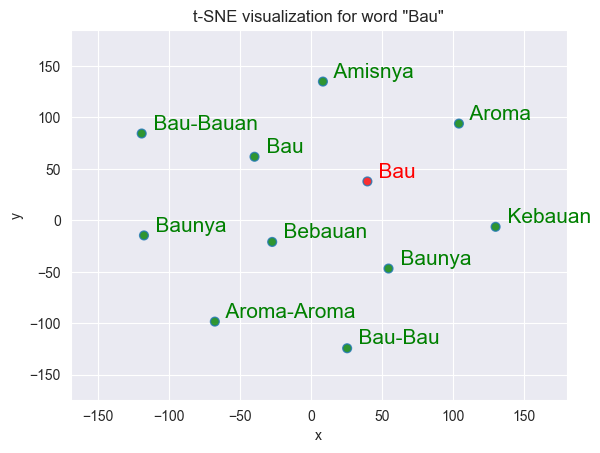

In [27]:
tsne_plot(for_word='bau', w2v_model=ft_model)

In [146]:
df_used = df[['num_pos_review', 'num_neg_review', 'num_jj_pos_review', 'num_jj_neg_review']]
df_merge = pd.concat([df_used.reset_index(drop=True), df_embedding], axis=1)
df_merge.head()

,num_pos_review,num_neg_review,num_jj_pos_review,num_jj_neg_review,0,1,2,3,4,5,...,290,291,292,293,294,295,296,297,298,299
0,0,1,0,0,0.014576,-0.012226,0.010872,-0.005993,-0.037455,-0.033761,...,0.001116,0.009118,-0.005093,0.015666,0.031078,0.043594,0.035579,0.027885,0.016291,0.058492
1,1,3,0,0,0.030862,-0.008655,-0.036939,-0.002987,-0.023031,-0.022818,...,0.009355,0.043653,-0.005753,-0.004318,-0.031764,0.036990,0.013729,-0.019661,0.006475,0.080892
2,2,1,1,0,0.038952,-0.088017,-0.075425,0.091268,0.083751,-0.034244,...,-0.018707,0.071034,-0.055746,0.044338,0.016490,0.036182,0.003229,0.017204,0.010311,-0.021546
3,5,4,3,2,0.016353,-0.042991,-0.021139,0.066199,0.013024,-0.014415,...,0.041994,0.021612,-0.013443,-0.017539,0.046575,0.051448,0.009958,-0.018741,0.042781,0.064199
4,8,8,3,3,0.043537,-0.044296,0.009503,0.047476,-0.031511,-0.060081,...,0.008068,0.009851,0.001524,0.029341,0.016110,0.035129,0.034869,-0.002092,0.005848,0.023731


In [147]:
VOCAB_SIZE = 2000  # perbesar lagi jika ukuran corpus lebih besar
MAX_LENGTH = 512

# untuk deep learning (Embedding Layer), setiap kata pada sebuah kalimat perlu di-encode
# ke integer (index di Embedding Layer)
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_LENGTH)

X_aux = df_merge
X_txt = df['review']
vectorize_layer.adapt(X_txt)

y = df[labels]

In [148]:
from sklearn.model_selection import train_test_split

X_aux_train, X_aux_val, X_txt_train, X_txt_val, y_train, y_val = train_test_split(X_aux, X_txt, y, test_size=0.2,
                                                                                  random_state=42)

X_aux_train.shape, X_aux_val.shape, X_txt_train.shape, X_txt_val.shape, y_train.shape, y_val.shape

((2047, 304), (512, 304), (2047,), (512,), (2047, 10), (512, 10))

In [149]:
y_train

,ac,air_panas,bau,general,kebersihan,linen,service,sunrise_meal,tv,wifi
363,1,0,1,2,1,0,2,1,1,1
1136,1,0,1,1,1,1,1,1,1,1
1227,0,1,1,1,0,1,2,1,1,1
1932,0,1,1,1,1,1,1,1,1,1
1486,1,1,0,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...
1645,0,1,1,1,1,1,1,1,1,1
1098,1,0,1,1,0,1,2,1,1,1
1133,1,1,0,2,2,1,1,1,1,1
1300,1,1,1,1,0,0,1,2,1,1


In [173]:
LEARNING_RATE = 1e-4
EMBEDDING_DIM = 128
RANDOM_STATE = 42

weight_initializer = tf.keras.initializers.GlorotNormal(seed=RANDOM_STATE)

# input dari auxilliary features (fitur NON-TEKS)
aux_input = tf.keras.Input(shape=(X_aux_train.shape[1],), \
                           name='aux_features')
hidden_aux = tf.keras.layers.Dense(16,
                                   activation='relu',
                                   kernel_initializer=weight_initializer,
                                   bias_initializer='zeros',
                                   kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                   bias_regularizer=tf.keras.regularizers.L1(1e-3))(aux_input)

# input dari text langsung (fitur di-ekstrak secara otomatis oleh arsitektur Deep Learning-nya)
text_input = tf.keras.Input(shape=(1,),
                            dtype=tf.string,
                            name='text')
ints = vectorize_layer(text_input)
# + 1 karena TokenVectorizer menambahkan OOV token ke Vocab
embeds = tf.keras.layers.Embedding(VOCAB_SIZE + 1, \
                                   EMBEDDING_DIM, \
                                   trainable=True)(ints)
hidden_out1 = tf.keras.layers.Dropout(0.1)(embeds)
time_distributed_hidden_out = tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32,
                                                                                kernel_regularizer=tf.keras.regularizers.L1(
                                                                                    l1=1e-3),
                                                                                recurrent_regularizer=tf.keras.regularizers.L1(
                                                                                    1e-3),
                                                                                return_sequences=True))(hidden_out1)
hidden_out2 = tf.keras.layers.Dense(16,
                                    activation='relu',
                                    kernel_initializer=weight_initializer,
                                    bias_initializer='zeros',
                                    kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                    bias_regularizer=tf.keras.regularizers.L1(1e-3))(time_distributed_hidden_out)
hidden_text = tf.keras.layers.GlobalAveragePooling1D()(hidden_out2)

# digabung hidden_aux dan hidden_text
concat_features = tf.keras.layers.concatenate([hidden_aux, hidden_text], axis=1)

output1 = tf.keras.layers.Dense(3,
                                activation='softmax',
                                kernel_initializer=weight_initializer,
                                bias_initializer='zeros',
                                name='out_ac',
                                kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                bias_regularizer=tf.keras.regularizers.L1(1e-3))(concat_features)

output2 = tf.keras.layers.Dense(3,
                                activation='softmax',
                                kernel_initializer=weight_initializer,
                                bias_initializer='zeros',
                                name='out_air_panas',
                                kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                bias_regularizer=tf.keras.regularizers.L1(1e-3))(concat_features)

output3 = tf.keras.layers.Dense(3,
                                activation='softmax',
                                kernel_initializer=weight_initializer,
                                bias_initializer='zeros',
                                name='out_bau',
                                kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                bias_regularizer=tf.keras.regularizers.L1(1e-3))(concat_features)

output4 = tf.keras.layers.Dense(3,
                                activation='softmax',
                                kernel_initializer=weight_initializer,
                                bias_initializer='zeros',
                                name='out_general',
                                kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                bias_regularizer=tf.keras.regularizers.L1(1e-3))(concat_features)

output5 = tf.keras.layers.Dense(3,
                                activation='softmax',
                                kernel_initializer=weight_initializer,
                                bias_initializer='zeros',
                                name='out_kebersihan',
                                kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                bias_regularizer=tf.keras.regularizers.L1(1e-3))(concat_features)

output6 = tf.keras.layers.Dense(3,
                                activation='softmax',
                                kernel_initializer=weight_initializer,
                                bias_initializer='zeros',
                                name='out_linen',
                                kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                bias_regularizer=tf.keras.regularizers.L1(1e-3))(concat_features)

output7 = tf.keras.layers.Dense(3,
                                activation='softmax',
                                kernel_initializer=weight_initializer,
                                bias_initializer='zeros',
                                name='out_service',
                                kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                bias_regularizer=tf.keras.regularizers.L1(1e-3))(concat_features)

output8 = tf.keras.layers.Dense(3,
                                activation='softmax',
                                kernel_initializer=weight_initializer,
                                bias_initializer='zeros',
                                name='out_sunrise_meal',
                                kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                bias_regularizer=tf.keras.regularizers.L1(1e-3))(concat_features)

output9 = tf.keras.layers.Dense(3,
                                activation='softmax',
                                kernel_initializer=weight_initializer,
                                bias_initializer='zeros',
                                name='out_tv',
                                kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                bias_regularizer=tf.keras.regularizers.L1(1e-3))(concat_features)

output10 = tf.keras.layers.Dense(3,
                                 activation='softmax',
                                 kernel_initializer=weight_initializer,
                                 bias_initializer='zeros',
                                 name='out_wifi',
                                 kernel_regularizer=tf.keras.regularizers.L1(l1=1e-3),
                                 bias_regularizer=tf.keras.regularizers.L1(1e-3))(concat_features)

model = tf.keras.Model([text_input, aux_input],
                       [output1, output2, output3, output4, output5, output6, output7, output8, output9, output10])

In [174]:
losses = {
    "out_ac": tf.keras.losses.CategoricalCrossentropy(),
    "out_air_panas": tf.keras.losses.CategoricalCrossentropy(),
    "out_bau": tf.keras.losses.CategoricalCrossentropy(),
    "out_general": tf.keras.losses.CategoricalCrossentropy(),
    "out_kebersihan": tf.keras.losses.CategoricalCrossentropy(),
    "out_linen": tf.keras.losses.CategoricalCrossentropy(),
    "out_service": tf.keras.losses.CategoricalCrossentropy(),
    "out_sunrise_meal": tf.keras.losses.CategoricalCrossentropy(),
    "out_tv": tf.keras.losses.CategoricalCrossentropy(),
    "out_wifi": tf.keras.losses.CategoricalCrossentropy(),
}

# loss_weights = {"out_sentimen_kutipan": 1.0, "out_sentimen_berita": 1.0}
def f1_score(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    return 2 * (precision * recall) / (precision + recall + K.epsilon())

model.compile(tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss=losses,
              # loss_weights = loss_weights,
              metrics=[f1_score])

print(model.summary())

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text (InputLayer)              [(None, 1)]          0           []                               
                                                                                                  
 text_vectorization_3 (TextVect  (None, 512)         0           ['text[0][0]']                   
 orization)                                                                                       
                                                                                                  
 embedding_4 (Embedding)        (None, 512, 128)     256128      ['text_vectorization_3[2][0]']   
                                                                                                  
 dropout_4 (Dropout)            (None, 512, 128)     0           ['embedding_4[0][0]']      

In [175]:
y_train['ac']

363     1
1136    1
1227    0
1932    0
1486    1
       ..
1645    0
1098    1
1133    1
1300    1
863     1
Name: ac, Length: 2047, dtype: int64

In [176]:
to_categorical(y_train['ac'].astype('int'))

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], dtype=float32)

In [177]:
{
    'out_ac': to_categorical(y_train['ac']),
    'out_air_panas': y_train['air_panas'].values,
    'out_bau': y_train['bau'].values,
    'out_general': y_train['general'].values,
    'out_kebersihan': y_train['kebersihan'].values,
    'out_linen': y_train['linen'].values,
    'out_service': y_train['service'].values,
    'out_sunrise_meal': y_train['sunrise_meal'].values,
    'out_tv': y_train['tv'].values,
    'out_wifi': y_train['wifi'].values,
}

{'out_ac': array([[0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        ...,
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.]], dtype=float32),
 'out_air_panas': array([0, 0, 1, ..., 1, 1, 1], dtype=int64),
 'out_bau': array([1, 1, 1, ..., 0, 1, 1], dtype=int64),
 'out_general': array([2, 1, 1, ..., 2, 1, 2], dtype=int64),
 'out_kebersihan': array([1, 1, 0, ..., 2, 0, 1], dtype=int64),
 'out_linen': array([0, 1, 1, ..., 1, 0, 1], dtype=int64),
 'out_service': array([2, 1, 2, ..., 1, 1, 1], dtype=int64),
 'out_sunrise_meal': array([1, 1, 1, ..., 1, 2, 1], dtype=int64),
 'out_tv': array([1, 1, 1, ..., 1, 1, 1], dtype=int64),
 'out_wifi': array([1, 1, 1, ..., 1, 1, 0], dtype=int64)}

In [178]:
BATCH_SIZE = 16
EPOCHS = 10

# Fit the model
# Tinggal tambahkan callback untuk save the best model on Validation data
with tf.device('/device:GPU:0'):
    model.fit(x=[X_txt_train, X_aux_train],
              y={
                  'out_ac': to_categorical(y_train['ac']),
                  'out_air_panas': to_categorical(y_train['air_panas']),
                  'out_bau': to_categorical(y_train['bau']),
                  'out_general': to_categorical(y_train['general']),
                  'out_kebersihan': to_categorical(y_train['kebersihan']),
                  'out_linen': to_categorical(y_train['linen']),
                  'out_service': to_categorical(y_train['service']),
                  'out_sunrise_meal': to_categorical(y_train['sunrise_meal']),
                  'out_tv': to_categorical(y_train['tv']),
                  'out_wifi': to_categorical(y_train['wifi']),
              },
              validation_data=(
                  [X_txt_val, X_aux_val],
                  {
                      'out_ac': to_categorical(y_val['ac']),
                      'out_air_panas': to_categorical(y_val['air_panas']),
                      'out_bau': to_categorical(y_val['bau']),
                      'out_general': to_categorical(y_val['general']),
                      'out_kebersihan': to_categorical(y_val['kebersihan']),
                      'out_linen': to_categorical(y_val['linen']),
                      'out_service': to_categorical(y_val['service']),
                      'out_sunrise_meal': to_categorical(y_val['sunrise_meal']),
                      'out_tv': to_categorical(y_val['tv']),
                      'out_wifi': to_categorical(y_val['wifi']),
                  }),
              batch_size=BATCH_SIZE,
              epochs=EPOCHS)

Epoch 1/10
128/128 [==============================] - 23s 94ms/step - loss: 11.0658 - out_ac_loss: 0.8367 - out_air_panas_loss: 0.7910 - out_bau_loss: 0.7649 - out_general_loss: 0.7378 - out_kebersihan_loss: 0.9717 - out_linen_loss: 0.8827 - out_service_loss: 0.9107 - out_sunrise_meal_loss: 0.7003 - out_tv_loss: 0.7084 - out_wifi_loss: 0.7555 - out_ac_f1_score: 0.5137 - out_air_panas_f1_score: 0.5538 - out_bau_f1_score: 0.5712 - out_general_f1_score: 0.5971 - out_kebersihan_f1_score: 0.3929 - out_linen_f1_score: 0.4700 - out_service_f1_score: 0.4553 - out_sunrise_meal_f1_score: 0.6236 - out_tv_f1_score: 0.6156 - out_wifi_f1_score: 0.5805 - val_loss: 9.6264 - val_out_ac_loss: 0.6787 - val_out_air_panas_loss: 0.6150 - val_out_bau_loss: 0.5919 - val_out_general_loss: 0.5248 - val_out_kebersihan_loss: 1.0195 - val_out_linen_loss: 0.8749 - val_out_service_loss: 0.8685 - val_out_sunrise_meal_loss: 0.5071 - val_out_tv_loss: 0.4828 - val_out_wifi_loss: 0.5968 - val_out_ac_f1_score: 0.8047 - va